

## **Preprocees the matches datset**




In [ ]:
import pandas as pd
import numpy as np
matches = pd.read_csv('/content/matches.csv')

cols_to_drop = ['match_type', 'player_of_match', 'target_runs', 'target_overs',
                'super_over', 'umpire1', 'umpire2', 'season', 'city', 'date',
                'toss_winner', 'toss_decision', 'result_margin', 'result', 'method',
                'team1', 'team2']
matches = matches.drop(columns=cols_to_drop)
print("Before handling the missing value")
print(matches.isnull().sum())
# Standardize team names '
team_mapping = {
    "Royal Challengers Bengaluru": "Royal Challengers Bangalore",
    "Rising Pune Supergiant": "Rising Pune Supergiants",
    "Delhi Daredevils": "Delhi Capitals",
    "Kings XI Punjab": "Punjab Kings"
}
matches['winner'] = matches['winner'].replace(team_mapping)
# Replace missing winners with 'No Result'
matches['winner'].fillna('No Result', inplace=True)
print("After handling the missing value")
# Verify that there are no more null values
print(matches.isnull().sum())


Before handling the missing value
id        0
venue     0
winner    5
dtype: int64
After handling the missing value
id        0
venue     0
winner    0
dtype: int64


<ipython-input-10-43ae2eebcf06>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  matches['winner'].fillna('No Result', inplace=True)


In [ ]:
# Map venues to canonical names (customize mapping as needed)
venue_mapping = {
    "M Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M.Chinnaswamy Stadium": "M Chinnaswamy Stadium",
    "M Chinnaswamy Stadium, Bengaluru": "M Chinnaswamy Stadium",

    "Punjab Cricket Association Stadium, Mohali": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium": "Punjab Cricket Association Stadium, Mohali",
    "Punjab Cricket Association IS Bindra Stadium, Mohali, Chandigarh": "Punjab Cricket Association Stadium, Mohali",

    "Wankhede Stadium": "Wankhede Stadium",
    "Wankhede Stadium, Mumbai": "Wankhede Stadium",

    "Eden Gardens": "Eden Gardens",
    "Eden Gardens, Kolkata": "Eden Gardens",

    "Sawai Mansingh Stadium": "Sawai Mansingh Stadium",
    "Sawai Mansingh Stadium, Jaipur": "Sawai Mansingh Stadium",

    "Rajiv Gandhi International Stadium, Uppal": "Rajiv Gandhi International Stadium, Hyderabad",
    "Rajiv Gandhi International Stadium, Uppal, Hyderabad": "Rajiv Gandhi International Stadium, Hyderabad",
    "Rajiv Gandhi International Stadium": "Rajiv Gandhi International Stadium, Hyderabad",

    "MA Chidambaram Stadium, Chepauk": "MA Chidambaram Stadium, Chepauk",
    "MA Chidambaram Stadium, Chepauk, Chennai": "MA Chidambaram Stadium, Chepauk",
    "MA Chidambaram Stadium": "MA Chidambaram Stadium, Chepauk",

    "Dr DY Patil Sports Academy": "Dr DY Patil Sports Academy",
    "Dr DY Patil Sports Academy, Mumbai": "Dr DY Patil Sports Academy",

    "Brabourne Stadium": "Brabourne Stadium",
    "Brabourne Stadium, Mumbai": "Brabourne Stadium",

    "Himachal Pradesh Cricket Association Stadium": "Himachal Pradesh Cricket Association Stadium",
    "Himachal Pradesh Cricket Association Stadium, Dharamsala": "Himachal Pradesh Cricket Association Stadium",

    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",
    "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam": "Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium",

    "Subrata Roy Sahara Stadium": "Subrata Roy Sahara Stadium",

    "Maharashtra Cricket Association Stadium": "Maharashtra Cricket Association Stadium",
    "Maharashtra Cricket Association Stadium, Pune": "Maharashtra Cricket Association Stadium",


    "Arun Jaitley Stadium": "Arun Jaitley Stadium, Delhi",
    "Arun Jaitley Stadium, Delhi": "Arun Jaitley Stadium, Delhi",
    "Feroz Shah Kotla":"Arun Jaitley Stadium, Delhi",

}
matches['venue_canonical'] = matches['venue'].map(venue_mapping).fillna(matches['venue'])
matches = matches[['match_id', 'winner', 'venue_canonical']]


KeyError: 'venue'

## **Preprocessing the deliveries datset**

In [ ]:
import pandas as pd

# Load datasets
df = pd.read_csv("/content/deliveries.csv")
# Display basic info
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder         

In [ ]:
# Check for missing values
print("\nMissing Values before handling:\n")
print(df.isnull().sum())


Missing Values before handling:

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


In [ ]:
# Define replacements for missing values
replacements = {
    "extras_type": "No Extra",
    "player_dismissed": "Not Out",
    "dismissal_kind": "Not Applicable",
    "fielder": "No Fielder Involved"
}
df.fillna(replacements, inplace=True)

In [ ]:
cols_deliveries = ['match_id', 'inning', 'batting_team', 'bowling_team',
                   'over', 'ball', 'total_runs', 'is_wicket']
deliveries_subset = df[cols_deliveries].copy()

# Standardize team names in deliveries data
for col in ['batting_team', 'bowling_team']:
    deliveries_subset[col] = deliveries_subset[col].replace(team_mapping)

deliveries_subset['cum_runs'] = deliveries_subset.groupby(['match_id', 'inning'])['total_runs'].cumsum()
deliveries_subset['cum_wickets'] = deliveries_subset.groupby(['match_id', 'inning'])['is_wicket'].cumsum()
deliveries_subset['overs_completed'] = deliveries_subset['over'] + (deliveries_subset['ball'] - 1) / 6
deliveries_subset['current_run_rate'] = np.where(
    deliveries_subset['overs_completed'] == 0,
    0,
    deliveries_subset['cum_runs'] / deliveries_subset['overs_completed']
)

In [ ]:

# 3. Compute Target & Required Run Rate (2nd Innings)

first_innings = deliveries_subset[deliveries_subset['inning'] == 1]
first_innings_final = first_innings.groupby('match_id')['cum_runs'].max().reset_index()
first_innings_final = first_innings_final.rename(columns={'cum_runs': 'first_innings_score'})
first_innings_final['target'] = first_innings_final['first_innings_score'] + 1

In [ ]:
print("Columns in deliveries_subset:", deliveries_subset.columns)
print("Columns in matches:", matches.columns)
print("Columns in first_innings_final:", first_innings_final.columns)


Columns in deliveries_subset: Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'total_runs', 'is_wicket', 'cum_runs', 'cum_wickets', 'overs_completed',
       'current_run_rate'],
      dtype='object')
Columns in matches: Index(['id', 'winner', 'venue_canonical'], dtype='object')
Columns in first_innings_final: Index(['match_id', 'first_innings_score', 'target'], dtype='object')


## **Merge two dataset**

In [ ]:
# Merge deliveries with matches and target info
matches.rename(columns={'id': 'match_id'}, inplace=True)
final_data = pd.merge(deliveries_subset, matches, on='match_id', how='left')
final_data = pd.merge(final_data, first_innings_final[['match_id', 'target']], on='match_id', how='left')

# Compute remaining overs
remaining_overs = 20 - final_data['overs_completed']
final_data['required_run_rate'] = np.where(
    (final_data['inning'] == 2) & (remaining_overs > 0),
    (final_data['target'] - final_data['cum_runs']) / remaining_overs,
    0
)
final_data['required_run_rate'] = final_data['required_run_rate'].replace([np.inf, -np.inf], 0)

# Create target variable: win = 1 if batting_team equals winner, else 0.
final_data['win'] = (final_data['batting_team'] == final_data['winner']).astype(int)

# Filter to second innings only (since required run rate applies to 2nd innings)
final_data = final_data[final_data['inning'] == 2].copy()

In [ ]:
keep_cols = ['match_id', 'inning', 'cum_runs', 'cum_wickets', 'current_run_rate',
             'required_run_rate', 'target', 'batting_team', 'bowling_team', 'venue_canonical', 'win']
final_data = final_data[keep_cols]
final_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125741 entries, 124 to 260919
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   match_id           125741 non-null  int64  
 1   inning             125741 non-null  int64  
 2   cum_runs           125741 non-null  int64  
 3   cum_wickets        125741 non-null  int64  
 4   current_run_rate   125741 non-null  float64
 5   required_run_rate  125741 non-null  float64
 6   target             125741 non-null  int64  
 7   batting_team       125741 non-null  object 
 8   bowling_team       125741 non-null  object 
 9   venue_canonical    125741 non-null  object 
 10  win                125741 non-null  int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 11.5+ MB


In [ ]:
# Rename the dataframe
merged_dataset = final_data.copy()

# Save as CSV
merged_dataset.to_csv('merged_dataset.csv', index=False)

print("Dataset saved as 'merged_dataset.csv'")


Dataset saved as 'merged_dataset.csv'


In [ ]:
print(merged_dataset.head())

     match_id  inning  cum_runs  cum_wickets  current_run_rate  \
124    335982       2         1            0               0.0   
125    335982       2         2            0              12.0   
126    335982       2         2            0               6.0   
127    335982       2         3            0               6.0   
128    335982       2         4            0               6.0   

     required_run_rate  target                 batting_team  \
124          11.100000     223  Royal Challengers Bangalore   
125          11.142857     223  Royal Challengers Bangalore   
126          11.237288     223  Royal Challengers Bangalore   
127          11.282051     223  Royal Challengers Bangalore   
128          11.327586     223  Royal Challengers Bangalore   

              bowling_team        venue_canonical  win  
124  Kolkata Knight Riders  M Chinnaswamy Stadium    0  
125  Kolkata Knight Riders  M Chinnaswamy Stadium    0  
126  Kolkata Knight Riders  M Chinnaswamy Stadium    

**Encoded dataset**

In [ ]:
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder

# Load your merged dataset
fd = pd.read_csv("merged_dataset.csv")

# Initialize separate LabelEncoders for each categorical column
batting_encoder = LabelEncoder()
bowling_encoder = LabelEncoder()
venue_encoder = LabelEncoder()

# Encode categorical columns using separate encoders
fd['batting_team'] = batting_encoder.fit_transform(fd['batting_team'])
fd['bowling_team'] = bowling_encoder.fit_transform(fd['bowling_team'])
fd['venue_canonical'] = venue_encoder.fit_transform(fd['venue_canonical'])

# Save the label-encoded dataset
fd.to_csv("merged_dataset_encoded.csv", index=False)
print("Label-encoded dataset saved as 'merged_dataset_encoded.csv'.")

# Save the LabelEncoders for later use
joblib.dump(batting_encoder, "batting_team_encoder.pkl")
joblib.dump(bowling_encoder, "bowling_team_encoder.pkl")
joblib.dump(venue_encoder, "venue_encoder.pkl")
print("Encoders saved successfully.")
fd = fd.drop(columns=['batting_team', 'bowling_team', 'venue_canonical'])

Label-encoded dataset saved as 'merged_dataset_encoded.csv'.
Encoders saved successfully.


**split the datset into train&test  split**

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load the encoded dataset
encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")
print(encoded_dataset.head())
# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features (ensure 'cum_wickets' exists in your dataset)
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target","venue_canonical"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check shapes of train and test sets
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



   match_id  inning  cum_runs  cum_wickets  current_run_rate  \
0    335982       2         1            0               0.0   
1    335982       2         2            0              12.0   
2    335982       2         2            0               6.0   
3    335982       2         3            0               6.0   
4    335982       2         4            0               6.0   

   required_run_rate  target  batting_team  bowling_team  venue_canonical  win  
0          11.100000     223            13             6               16    0  
1          11.142857     223            13             6               16    0  
2          11.237288     223            13             6               16    0  
3          11.282051     223            13             6               16    0  
4          11.327586     223            13             6               16    0  
Training Data Shape: (100592, 8)
Testing Data Shape: (25149, 8)


**Logistic Regression**


=== Training Set Evaluation ===
Training Accuracy: 0.97

Training Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     95856
           1       0.75      0.39      0.51      4736

    accuracy                           0.97    100592
   macro avg       0.86      0.69      0.75    100592
weighted avg       0.96      0.97      0.96    100592


Training Confusion Matrix:
[[95256   600]
 [ 2888  1848]]


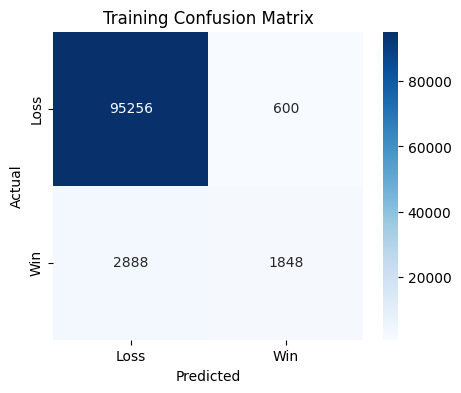


=== Testing Set Evaluation ===
Testing Accuracy: 0.96

Testing Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     23924
           1       0.75      0.36      0.49      1225

    accuracy                           0.96     25149
   macro avg       0.86      0.68      0.73     25149
weighted avg       0.96      0.96      0.96     25149


Testing Confusion Matrix:
[[23776   148]
 [  783   442]]


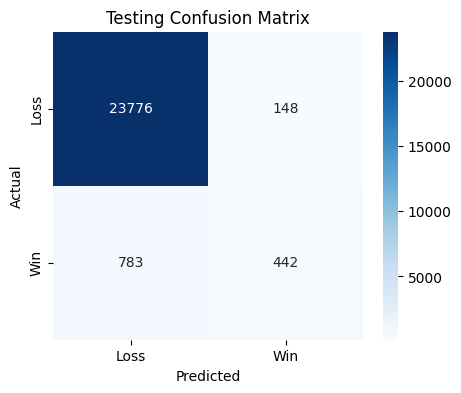


Predicted Outcome: Bowling team wins


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the encoded dataset
encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")

# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

# Generate predictions for both Training and Testing Sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Evaluate model performance on the Training Set
print("\n=== Training Set Evaluation ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.2f}")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

train_cm = confusion_matrix(y_train, y_train_pred)
print("\nTraining Confusion Matrix:")
print(train_cm)

# Plot Training Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(train_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Training Confusion Matrix")
plt.show()

# Evaluate model performance on the Testing Set
print("\n=== Testing Set Evaluation ===")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.2f}")
print("\nTesting Classification Report:\n", classification_report(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
print("\nTesting Confusion Matrix:")
print(test_cm)

# Plot Testing Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Testing Confusion Matrix")
plt.show()

# Predict on a new sample (replace values with actual match details)
sample_input = pd.DataFrame([[3, 5, 2, 2, 7.8, 9.5, 180]],  # Example values
                            columns=features)

sample_prediction = model.predict(sample_input)
print("\nPredicted Outcome:", "Batting team wins" if sample_prediction[0] == 1 else "Bowling team wins")


**SVM model**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the encoded dataset
encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")

# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target","venue_canonical"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### === SUPPORT VECTOR MACHINE (SVM) MODEL === ###
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)

# Predictions for training and testing sets
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# Evaluation - Training Set
print("\n=== SVM Training Set Evaluation ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_svm):.2f}")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred_svm))

train_cm_svm = confusion_matrix(y_train, y_train_pred_svm)
print("\nTraining Confusion Matrix (SVM):")
print(train_cm_svm)

# Evaluation - Testing Set
print("\n=== SVM Testing Set Evaluation ===")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_svm):.2f}")
print("\nTesting Classification Report:\n", classification_report(y_test, y_test_pred_svm))

test_cm_svm = confusion_matrix(y_test, y_test_pred_svm)
print("\nTesting Confusion Matrix (SVM):")
print(test_cm_svm)

# Plot Confusion Matrix for SVM (Testing Set)
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm_svm, annot=True, fmt="d", cmap="Reds", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Testing Confusion Matrix - SVM")
plt.show()

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the encoded dataset
encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")

# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### === SUPPORT VECTOR MACHINE (SVM) MODEL === ###
svm_model = SVC(kernel='linear', C=1)
svm_model.fit(X_train, y_train)

# Predictions for training and testing sets
y_train_pred_svm = svm_model.predict(X_train)
y_test_pred_svm = svm_model.predict(X_test)

# Evaluation - Training Set
print("\n=== SVM Training Set Evaluation ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred_svm):.2f}")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred_svm))

train_cm_svm = confusion_matrix(y_train, y_train_pred_svm)
print("\nTraining Confusion Matrix (SVM):")
print(train_cm_svm)

# Evaluation - Testing Set
print("\n=== SVM Testing Set Evaluation ===")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred_svm):.2f}")
print("\nTesting Classification Report:\n", classification_report(y_test, y_test_pred_svm))

test_cm_svm = confusion_matrix(y_test, y_test_pred_svm)
print("\nTesting Confusion Matrix (SVM):")
print(test_cm_svm)

# Plot Confusion Matrix for SVM (Testing Set)
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm_svm, annot=True, fmt="d", cmap="Reds", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Testing Confusion Matrix - SVM")
plt.show()

# Predict on a new sample (replace values with actual match details)
sample_input = pd.DataFrame([[3, 5, 2, 2, 7.8, 9.5, 180]],  # Example values
                            columns=features)

svm_sample_prediction = svm_model.predict(sample_input)

print("\nSVM Predicted Outcome:", "Batting team wins" if svm_sample_prediction[0] == 1 else "Bowling team wins")




**Random forst clssifier model**


=== Random Forest Training Set Evaluation ===
Training Accuracy: 0.99707

Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     83860
           1       1.00      0.94      0.97      4158

    accuracy                           1.00     88018
   macro avg       1.00      0.97      0.98     88018
weighted avg       1.00      1.00      1.00     88018


Training Confusion Matrix:
[[83852     8]
 [  250  3908]]


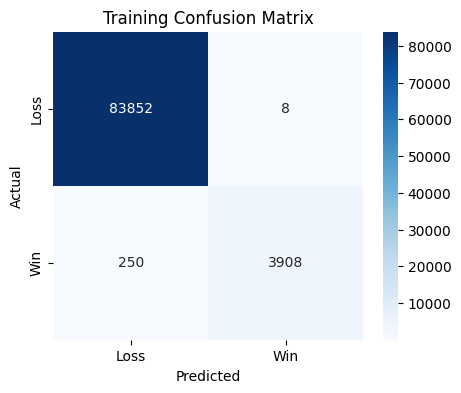


=== Random Forest Testing Set Evaluation ===
Testing Accuracy: 0.9964

Testing Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35920
           1       1.00      0.93      0.96      1803

    accuracy                           1.00     37723
   macro avg       1.00      0.96      0.98     37723
weighted avg       1.00      1.00      1.00     37723


Testing Confusion Matrix:
[[35912     8]
 [  128  1675]]


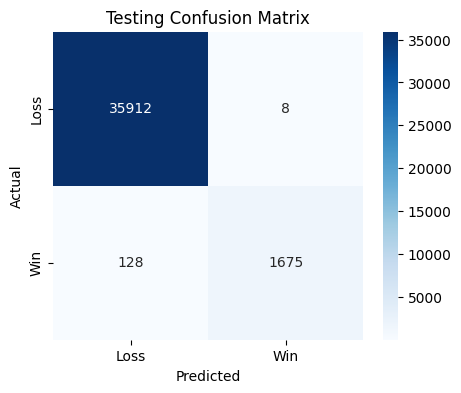


Model saved successfully as 'random_forest_model.pkl'


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- venue_canonical


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the encoded dataset
encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")

# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target","venue_canonical"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize and train the Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Generate predictions for both Training and Testing sets
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Evaluate model performance on the Training Set
print("\n=== Random Forest Training Set Evaluation ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.5f}")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

train_cm = confusion_matrix(y_train, y_train_pred)
print("\nTraining Confusion Matrix:")
print(train_cm)

# Plot Training Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(train_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Training Confusion Matrix")
plt.show()

# Evaluate model performance on the Testing Set
print("\n=== Random Forest Testing Set Evaluation ===")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nTesting Classification Report:\n", classification_report(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
print("\nTesting Confusion Matrix:")
print(test_cm)

# Plot Testing Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Testing Confusion Matrix")
plt.show()
import joblib

# Save the best trained Random Forest model
joblib.dump(rf_model, "random_forest_modelfinal.pkl")
print("\nModel saved successfully as 'random_forest_model.pkl'")
# Load the trained model
rf_model = joblib.load("random_forest_model.pkl")

# Use the loaded model for predictions
y_pred = rf_model.predict(X_test)
print(f"\nReloaded Model Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")



Fitting 2 folds for each of 162 candidates, totalling 324 fits

Best Parameters: {'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

=== Random Forest Training Set Evaluation ===
Training Accuracy: 0.99961

Training Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     83860
           1       1.00      0.99      1.00      4158

    accuracy                           1.00     88018
   macro avg       1.00      1.00      1.00     88018
weighted avg       1.00      1.00      1.00     88018


Training Confusion Matrix:
[[83855     5]
 [   29  4129]]


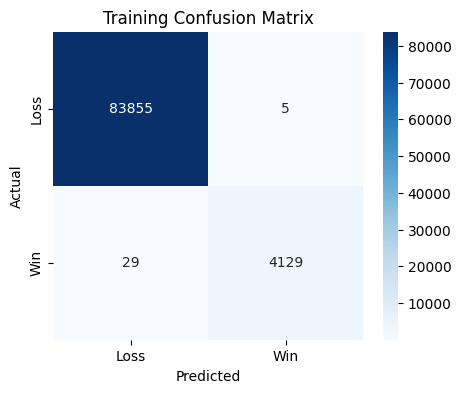


=== Random Forest Testing Set Evaluation ===
Testing Accuracy: 0.9982

Testing Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     35920
           1       0.99      0.98      0.98      1803

    accuracy                           1.00     37723
   macro avg       0.99      0.99      0.99     37723
weighted avg       1.00      1.00      1.00     37723


Testing Confusion Matrix:
[[35897    23]
 [   45  1758]]


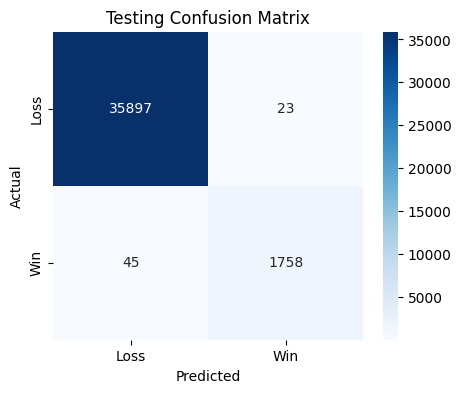

In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load the encoded dataset

encoded_dataset = pd.read_csv("merged_dataset_encoded.csv")

# Create binary 'win' column (1 if batting team wins, else 0)
encoded_dataset['win'] = encoded_dataset.apply(lambda row: 1 if row['win'] == row['batting_team'] else 0, axis=1)

# Selecting required features
features = ["batting_team", "bowling_team", "inning", "cum_wickets",
            "current_run_rate", "required_run_rate", "target"]
target = "win"

# Keep only the necessary columns
encoded_dataset = encoded_dataset[features + [target]]

# Train-Test Split (80-20)
X = encoded_dataset.drop(columns=['win'])
y = encoded_dataset['win']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

### === GRID SEARCH FOR RANDOM FOREST === ###
param_grid = {
    'n_estimators': [50, 100, 200],        # Number of trees
    'max_depth': [5, 10, 15],              # Limit tree depth
    'min_samples_split': [2, 5, 10],       # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 5],         # Minimum samples per leaf
    'max_features': ['sqrt', 'log2']       # Feature selection strategy
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=2, scoring='accuracy', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best parameters
print("\nBest Parameters:", grid_search.best_params_)

# Train best model
best_rf_model = grid_search.best_estimator_

# Predictions for training and testing sets
y_train_pred = best_rf_model.predict(X_train)
y_test_pred = best_rf_model.predict(X_test)

# Evaluation - Training Set
print("\n=== Random Forest Training Set Evaluation ===")
print(f"Training Accuracy: {accuracy_score(y_train, y_train_pred):.5f}")
print("\nTraining Classification Report:\n", classification_report(y_train, y_train_pred))

train_cm = confusion_matrix(y_train, y_train_pred)
print("\nTraining Confusion Matrix:")
print(train_cm)

# Plot Confusion Matrix for Training Set
plt.figure(figsize=(5, 4))
sns.heatmap(train_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Training Confusion Matrix")
plt.show()

# Evaluation - Testing Set
print("\n=== Random Forest Testing Set Evaluation ===")
print(f"Testing Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print("\nTesting Classification Report:\n", classification_report(y_test, y_test_pred))

test_cm = confusion_matrix(y_test, y_test_pred)
print("\nTesting Confusion Matrix:")
print(test_cm)

# Plot Confusion Matrix for Testing Set
plt.figure(figsize=(5, 4))
sns.heatmap(test_cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Loss", "Win"], yticklabels=["Loss", "Win"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Testing Confusion Matrix")
plt.show()




In [ ]:
import joblib

# Save the best trained Random Forest model
joblib.dump(rf_model, "random_forest_modelfinal.pkl")
print("\nModel saved successfully as 'random_forest_model.pkl'")
# Load the trained model
rf_model = joblib.load("random_forest_modelfinal.pkl")

# Use the loaded model for predictions
y_pred = rf_model.predict(X_test)
print(f"\nReloaded Model Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")



Model saved successfully as 'random_forest_model.pkl'


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- venue_canonical


In [37]:
user_input = {
    'inning': 1,
    'cum_runs': 80,            # current cumulative runs
    'cum_wickets': 5,          # current wickets lost
    'overs_completed': 12.0,    # overs completed so far
    'target': 0,             # target score
    'batting_team': "Chennai Super Kings",
    'bowling_team': "Mumbai Indians",
    'venue': "Wankhede Stadium"  # assume this maps to a canonical venue (e.g., "Wankhede Stadium")
}
# Compute current run rate
if user_input['overs_completed'] > 0:
    current_run_rate = user_input['cum_runs'] / user_input['overs_completed']
else:
    current_run_rate = 0

# Compute required run rate
remaining_overs = 20 - user_input['overs_completed']
if user_input['inning'] == 2 and remaining_overs > 0:
    required_run_rate = (user_input['target'] - user_input['cum_runs']) / remaining_overs
else:
    required_run_rate = 0


# ---------------------------
# 2. Load Saved Encoders and Model
# ---------------------------
# Load the team and venue LabelEncoders (ensure these files were saved during training)
import pandas as pd
import joblib
batting_encoder = joblib.load("batting_team_encoder.pkl")
bowling_encoder = joblib.load("bowling_team_encoder.pkl")
venue_encoder = joblib.load("venue_encoder.pkl")

# Load the trained RandomForest model
rf_model = joblib.load("random_forest_modelfinal.pkl")  # Make sure you saved the model earlier
# 3. Encode Categorical Variables
# ---------------------------
# Encode batting team and bowling team using the team encoder
batting_team_encoded = batting_encoder.transform([user_input['batting_team']])[0]
bowling_team_encoded = bowling_encoder.transform([user_input['bowling_team']])[0]

# Encode the venue using the venue encoder
venue_canonical_encoded = venue_encoder.transform([user_input['venue']])[0]
input_data = {
    'inning': [user_input['inning']],
    'cum_runs': [user_input['cum_runs']],
    'cum_wickets': [user_input['cum_wickets']],
    'current_run_rate': [current_run_rate],
    'required_run_rate': [required_run_rate],
    'target': [user_input['target']],
    'batting_team_encoded': [batting_team_encoded],
    'bowling_team': [bowling_team_encoded],
    'venue_canonical': [venue_canonical_encoded]
}


input_df = pd.DataFrame(input_data)
prediction = rf_model.predict(input_df)[0]
predicted_probabilities = rf_model.predict_proba(input_df)[0]

# ---------------------------
# 6. Map Prediction to Team Names
# ---------------------------
if prediction == 1:
    predicted_winner = user_input['batting_team']
else:
    predicted_winner = user_input['bowling_team']

print("Predicted Winner:", predicted_winner)
print("Prediction Probabilities (Loss, Win):", predicted_probabilities)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- batting_team_encoded
- bowling_team_encoded
- cum_runs
- venue_canonical_encoded
Feature names seen at fit time, yet now missing:
- batting_team
- bowling_team
- venue_canonical


In [ ]:
user_input = {
    'inning': 1,
    'cum_runs': 80,            # current cumulative runs
    'cum_wickets': 5,          # current wickets lost
    'overs_completed': 12.0,    # overs completed so far
    'target': 0,               # target score
    'batting_team': "Mumbai Indians",
    'bowling_team': "Chennai Super Kings",
    'venue': "Wankhede Stadium"
}

# Compute current run rate
if user_input['overs_completed'] > 0:
    current_run_rate = user_input['cum_runs'] / user_input['overs_completed']
else:
    current_run_rate = 0

# Compute required run rate
remaining_overs = 20 - user_input['overs_completed']
if user_input['inning'] == 2 and remaining_overs > 0:
    required_run_rate = (user_input['target'] - user_input['cum_runs']) / remaining_overs
else:
    required_run_rate = 0

# ---------------------------
# Load Saved Encoders and Model
# ---------------------------
import pandas as pd
import joblib

batting_encoder = joblib.load("batting_team_encoder.pkl")
bowling_encoder = joblib.load("bowling_team_encoder.pkl")
venue_encoder = joblib.load("venue_encoder.pkl")

# Load the trained RandomForest model
rf_model = joblib.load("random_forest_model.pkl")  # Ensure the model is saved correctly

# ---------------------------
# Encode Categorical Variables
# ---------------------------
batting_team_encoded = batting_encoder.transform([user_input['batting_team']])[0]
bowling_team_encoded = bowling_encoder.transform([user_input['bowling_team']])[0]
venue_encoded = venue_encoder.transform([user_input['venue']])[0]

# ---------------------------
# Prepare Input Data (Including Venue)
# ---------------------------
input_data = {
    'batting_team': [batting_team_encoded],
    'bowling_team': [bowling_team_encoded],
    'venue': [venue_encoded],  # Include encoded venue
    'inning': [user_input['inning']],
    'cum_wickets': [user_input['cum_wickets']],
    'current_run_rate': [current_run_rate],
    'required_run_rate': [required_run_rate],
    'target': [user_input['target']]
}

input_df = pd.DataFrame(input_data)

# ---------------------------
# Predict Using the Model
# ---------------------------
prediction = rf_model.predict(input_df)[0]
predicted_probabilities = rf_model.predict_proba(input_df)[0]

# ---------------------------
# Map Prediction to Team Names
# ---------------------------
predicted_winner = user_input['batting_team'] if prediction == 1 else user_input['bowling_team']

print("Predicted Winner:", predicted_winner)
print("Prediction Probabilities (Loss, Win):", predicted_probabilities)


ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- venue


In [ ]:
print(rf_model.feature_names_in_)


['batting_team' 'bowling_team' 'inning' 'cum_wickets' 'current_run_rate'
 'required_run_rate' 'target']
